In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## Load MNIST Dataset

In [2]:
batch_size = 128

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.02MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]


## VAE Architecture

### Encoder → produces μ and log(σ²)
### Decoder → reconstructs image from latent vector

In [3]:
class VAE(nn.Module):

    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, 20)
        self.fc_logvar = nn.Linear(400, 20)

        # Decoder
        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    # Encoder
    def encode(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    # Reparameterization
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    # Decoder
    def decode(self, z):
        h = self.relu(self.fc3(z))
        return self.sigmoid(self.fc4(h))

    # Forward Pass
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

## Loss Function

### The total VAE loss consists of:

* ### Reconstruction Loss : Measures difference between input and output.



* ### KL Divergence Loss : Forces latent space to follow a normal distribution.

    * The KL divergence formula used in VAE is: D_{KL}(q(z|x) || p(z)) = -\frac{1}{2} \sum (1 + \log(\sigma^2) - \mu^2 - \sigma^2)

In [4]:
def loss_function(recon_x, x, mu, logvar):

    # Reconstruction Loss
    recon_loss = nn.functional.binary_cross_entropy(
        recon_x, x, reduction='sum'
    )

    # KL Divergence Loss
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss, recon_loss, kl_loss

## Initialize Model

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## Training Loop

In [6]:
epochs = 10

for epoch in range(epochs):

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for batch_idx, (data, _) in enumerate(train_loader):

        data = data.view(-1, 784).to(device)

        optimizer.zero_grad()

        # Forward Pass
        reconstruction, mu, logvar = model(data)

        # Compute Loss
        loss, recon_loss, kl_loss = loss_function(
            reconstruction, data, mu, logvar
        )

        # Backpropagation
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    print(f"Epoch {epoch+1}")
    print("Total Loss:", total_loss/len(train_loader.dataset))
    print("Reconstruction Loss:", total_recon/len(train_loader.dataset))
    print("KL Divergence Loss:", total_kl/len(train_loader.dataset))
    print("-"*40)

Epoch 1
Total Loss: 164.89785478515626
Reconstruction Loss: 149.6620212076823
KL Divergence Loss: 15.235833811124166
----------------------------------------
Epoch 2
Total Loss: 122.18623732096354
Reconstruction Loss: 100.17293517252604
KL Divergence Loss: 22.013302197265624
----------------------------------------
Epoch 3
Total Loss: 114.94463235677084
Reconstruction Loss: 91.15238081054687
KL Divergence Loss: 23.79225146077474
----------------------------------------
Epoch 4
Total Loss: 111.92845180664062
Reconstruction Loss: 87.54460415039063
KL Divergence Loss: 24.383847648111978
----------------------------------------
Epoch 5
Total Loss: 110.169581640625
Reconstruction Loss: 85.51025506184895
KL Divergence Loss: 24.659326692708333
----------------------------------------
Epoch 6
Total Loss: 108.98690545247396
Reconstruction Loss: 84.12881350911458
KL Divergence Loss: 24.858091935221353
----------------------------------------
Epoch 7
Total Loss: 108.06558852539062
Reconstruction 

## Latent Space Visualization

In [7]:
import matplotlib.pyplot as plt

def visualize_latent_space(model, loader):

    model.eval()

    z_points = []
    labels = []

    with torch.no_grad():
        for data, target in loader:

            data = data.view(-1,784).to(device)

            mu, logvar = model.encode(data)
            z = model.reparameterize(mu, logvar)

            z_points.append(z.cpu())
            labels.append(target)

    z_points = torch.cat(z_points)
    labels = torch.cat(labels)

    plt.figure(figsize=(8,6))
    plt.scatter(z_points[:,0], z_points[:,1], c=labels, cmap="tab10", s=5)
    plt.colorbar()
    plt.title("Latent Space Visualization")
    plt.xlabel("Z1")
    plt.ylabel("Z2")
    plt.show()

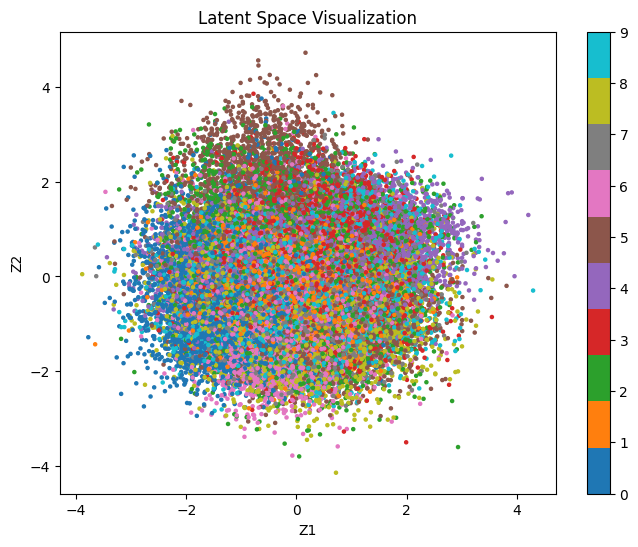

In [8]:
visualize_latent_space(model, train_loader)

## Generated Digit Samples

In [9]:
def generate_digits(model, num_samples=16):

    model.eval()

    with torch.no_grad():

        z = torch.randn(num_samples, 20).to(device)
        samples = model.decode(z).cpu()

        samples = samples.view(num_samples, 28, 28)

        plt.figure(figsize=(6,6))

        for i in range(num_samples):
            plt.subplot(4,4,i+1)
            plt.imshow(samples[i], cmap='gray')
            plt.axis("off")

        plt.suptitle("Generated Digits from Latent Space")
        plt.show()

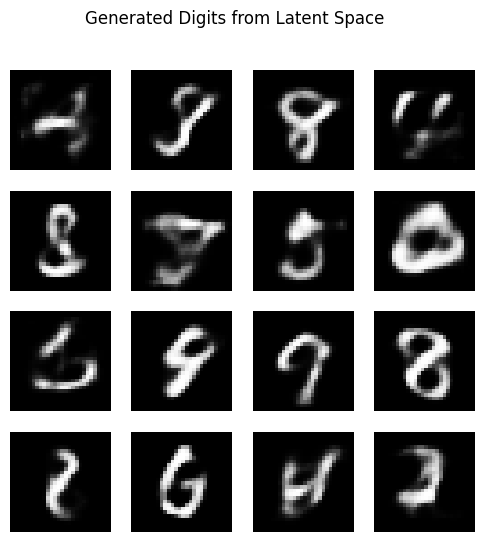

In [10]:
generate_digits(model)

## Reconstruction Comparison

In [11]:
def show_reconstructions(model, loader):

    model.eval()

    data, _ = next(iter(loader))
    data = data[:8].to(device)

    with torch.no_grad():
        recon, _, _ = model(data.view(-1,784))

    recon = recon.view(-1,28,28).cpu()
    data = data.cpu()

    plt.figure(figsize=(10,4))

    for i in range(8):

        # Original
        plt.subplot(2,8,i+1)
        plt.imshow(data[i].squeeze(), cmap='gray')
        plt.axis("off")

        # Reconstructed
        plt.subplot(2,8,i+9)
        plt.imshow(recon[i], cmap='gray')
        plt.axis("off")

    plt.suptitle("Top: Original | Bottom: Reconstructed")
    plt.show()

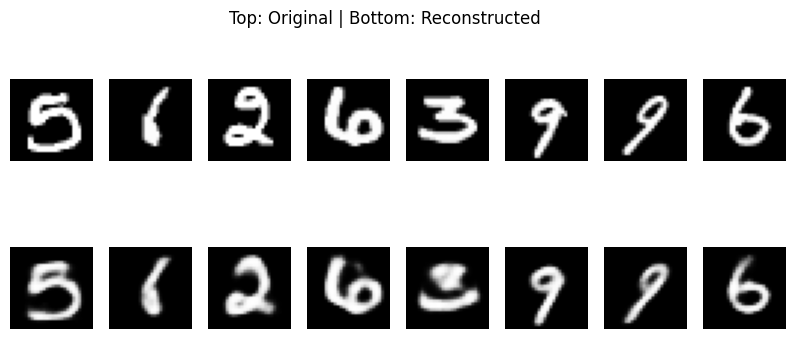

In [12]:
show_reconstructions(model, train_loader)